# Set up

_Note: **Do not run any tensorflow line when TabNet**_

In [1]:
pip install pytorch-tabnet

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
  Using cached grpcio-1.80.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-

In [2]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Base library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Metrics
from sklearn.model_selection import GridSearchCV,train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,PredictionErrorDisplay, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [5]:
#NN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

I0000 00:00:1779230249.613004     222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779230249.661239     222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779230250.851615     222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
#For TabNet DO NOT RUN
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [6]:
import xgboost as xgb

In [7]:
import os
import warnings
warnings.filterwarnings("ignore")

# Dataset

## Load and clean

In [8]:
data = pd.read_csv("spotify_dataset.csv").copy()

Duplicates come with different popularity score, first the df will be sorted by popularity and track id in order to drop the duplicates with the lower popularity score.

In [9]:
df_sorted = data.sort_values(by=['popularity', 'track_id'], ascending=[False, True], kind='mergesort')
df_cleaned = df_sorted.drop_duplicates(subset='track_id', keep='first')
df = df_cleaned.copy()

The objective is identify if the songs are hit, thus the tracks that are not of musical genre are discarded.

In [10]:
#Remove comedy, kids, children
df = df[df['track_genre'] != 'comedy']
df = df[df['track_genre'] != 'kids']
df = df[df['track_genre'] != 'children']
#Convert into numeric values
df['explicit'].replace({False: 0, True: 1}, inplace=True)

The columns to be discarded based on their relevance and literature recommendation (key). Track_genre is discarded since the genres may be not completely accurate.

In [11]:
drop_cols = [
    "Unnamed: 0",
    "track_id",
    "track_name",
    "album_name",
    "artists",
    'track_genre',
    'key'
]
feature_cols = [c for c in df.columns if c not in drop_cols]

df = df[feature_cols].copy()

In [12]:
#Identify numeric and categorical features
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical features: []


The objective is differenciate songs that are are hit or not, a song with popularity 0 can be considered a non-hit, however this task has to focused on a hit song and it has to learn more about positive characteristics, therefore all songs with popularity = 0 are discarded.

In [13]:
df = df[df['popularity'] > 0]

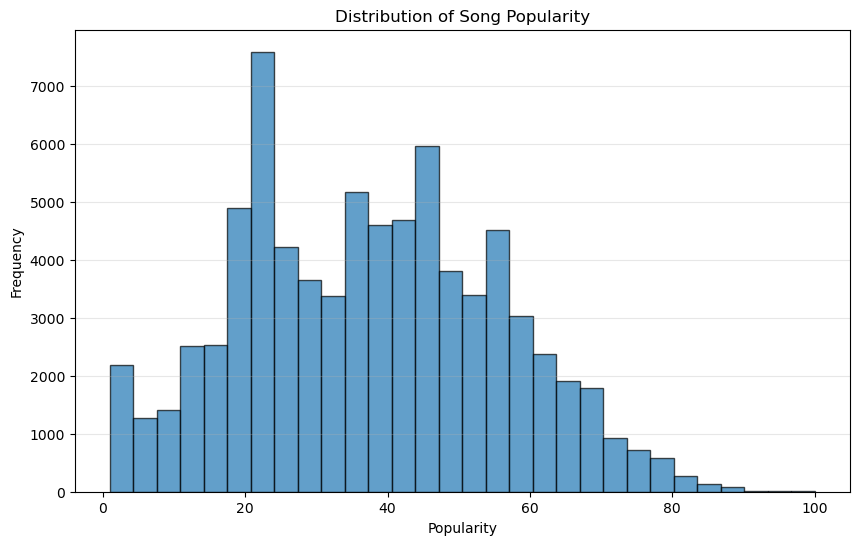

In [14]:
#Histogram of popularity distribution
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Song Popularity')
plt.grid(axis='y', alpha=0.3)
plt.show()

To establish song that can be considered as hit or not, it was set a threshold basen on the median, since the median is the value that is approximately at the middle of the data.

In [15]:
median = df['popularity'].median()
median

37.0

In [16]:
#Define is hit if the popularity is greater or equal than the median
df["is_hit"] = (df["popularity"] >= int(median)).astype(int)

To know the size of the df and the proportion of the classes

In [17]:
print(df.shape)
print(df["is_hit"].value_counts())
print(df["is_hit"].value_counts(normalize=True))
df.head()

(77580, 15)
is_hit
1    40181
0    37399
Name: count, dtype: int64
is_hit
1    0.51793
0    0.48207
Name: proportion, dtype: float64


,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,is_hit
20001,100,156943,0,0.714,0.472,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,1
51664,99,198937,0,0.621,0.782,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,1
20008,98,175238,1,0.561,0.965,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,1
67356,98,162637,0,0.835,0.679,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,1
67359,97,243716,0,0.650,0.715,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,1


From the above results, the accuracy to overcome is **0.51**

In [18]:
#Drop popularity since this is a classification task
df = df.drop(['popularity'], axis=1)

In [19]:
#Define the variables to work on
X = df.drop(columns=['is_hit'])
y = df['is_hit']

Redefine each type of columns

In [20]:
#Numeric
numeric_features = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
#Categorical
categorical_features = ['time_signature']
#Binary
binary_features = ['mode', 'explicit']

Preprocess the data by their type

In [21]:
#Preprocessor
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("bin", "passthrough")
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features)
])

## Split data

To avoid data leakage the flow will be:
1. Split the data.
2. Transform it using the preprocessor defined above.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(62064, 13) (15516, 13)
0.5179331013147719 0.5179169889146688


In [23]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [24]:
column_names = preprocessor.get_feature_names_out()

# Classification methods

Define a function to get the metrics for classification and plots

In [25]:
def class_metrics(y_test, model, X_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1-score :", round(f1_score(y_test, y_pred), 4))
    print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))
    
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred, target_names=['Non-Hit', 'Hit']))
    print("\nMetrics plots:\n")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Non-Hit", "Hit"],
        colorbar=False,
        cmap='Blues',
        ax=axes[0])
    axes[0].set_title("Confusion Matrix")
    
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
    axes[1].set_title("ROC Curve")
    
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
    axes[2].set_title("Precision-Recall Curve")
    
    plt.tight_layout()
    plt.show()

In [26]:
def plot_training(history_model):
    #PLot the training performance
    plt.figure(figsize = (10,4))
    plt.subplot(121)
    plt.plot(history_model.history['loss'],label="train")
    plt.plot(history_model.history['val_loss'],label="validation")
    plt.title('Model Loss')
    plt.yscale('log')
    plt.ylabel('Cross Entropy')
    plt.xlabel('Iteration')
    plt.grid()
    plt.legend()
    #print("history",history_model.history)
    plt.subplot(122)
    plt.plot(history_model.history['sparse_categorical_accuracy'],label="train")
    plt.plot(history_model.history['val_sparse_categorical_accuracy'],label="validation")
    plt.title('Model Accuracy')
    #plt.yscale('log')
    plt.ylabel('Acc')
    plt.xlabel('Iteration')
    plt.grid()
    plt.legend()
    plt.show()

Define the size of the input for NN methods

In [27]:
n_cols = X_train_scaled.shape[1]

## Baseline Logistic Regression

In [28]:
#Define LgR and fit
lgr = LogisticRegression(max_iter=1000, random_state=42)
lgr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Accuracy : 0.5925
Precision: 0.594
Recall   : 0.6736
F1-score : 0.6313
ROC AUC  : 0.6344

Classification report:

              precision    recall  f1-score   support

     Non-Hit       0.59      0.51      0.54      7480
         Hit       0.59      0.67      0.63      8036

    accuracy                           0.59     15516
   macro avg       0.59      0.59      0.59     15516
weighted avg       0.59      0.59      0.59     15516


Metrics plots:



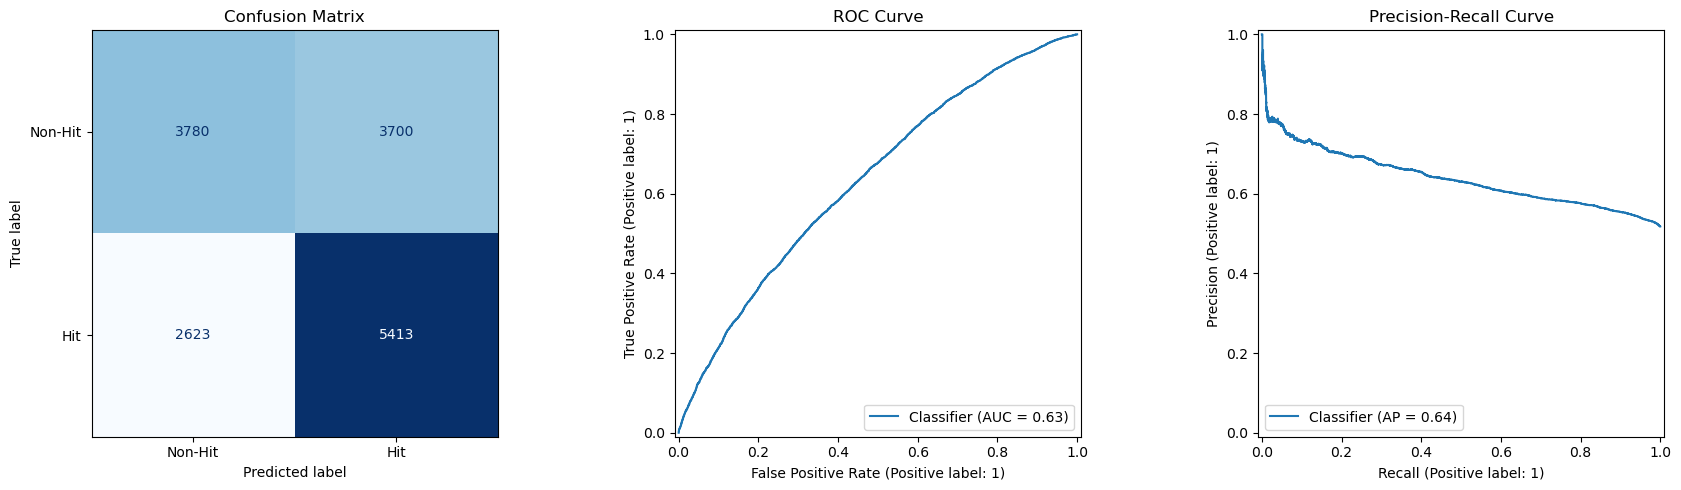

In [29]:
#Metrics
class_metrics(y_test, lgr, X_test_scaled)

## XGBoost
Tree based algorithms do not need scaled input

In [30]:
#Define parameters to try to use GridSearchCV 
params_grid = {
    'learning_rate': [0.01, 0.05],
    'gamma':[0, 0.01],
    'max_depth': [7, 8],
    'min_child_weight': [0,1, 2],
    'subsample': [0.7,0.8],
    'n_estimators': [300,400, 600],
    'colsample_bytree':[0.8, 1],
    'random_state':[2000]    
}
classifier = xgb.XGBClassifier()
#USing f1 since it considers recall and precision metrics at the same time
grid_classifier = GridSearchCV(classifier, params_grid, scoring='f1', cv=5, n_jobs=-1)

In [31]:
#Fit the grid search cv
grid_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1], 'gamma': [0, 0.01],
                         'learning_rate': [0.01, 0.05], 'max_depth': [7, 8],
                         'min_child_weight': [0, 1, 2],
                         'n_estimators': [300, 400, 600],
                         'random_state': [2000], 'subsample': [0.7, 0.8]},
             scoring='f1')

In [32]:
#Show the best parameters obtained
best_parameters = grid_classifier.best_params_
best_parameters

{'colsample_bytree': 1,
 'gamma': 0,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 0,
 'n_estimators': 600,
 'random_state': 2000,
 'subsample': 0.8}

In [33]:
best_xgb_model = grid_classifier.best_estimator_

Accuracy : 0.6744
Precision: 0.6622
Recall   : 0.7581
F1-score : 0.7069
ROC AUC  : 0.7394

Classification report:

              precision    recall  f1-score   support

     Non-Hit       0.69      0.58      0.63      7480
         Hit       0.66      0.76      0.71      8036

    accuracy                           0.67     15516
   macro avg       0.68      0.67      0.67     15516
weighted avg       0.68      0.67      0.67     15516


Metrics plots:



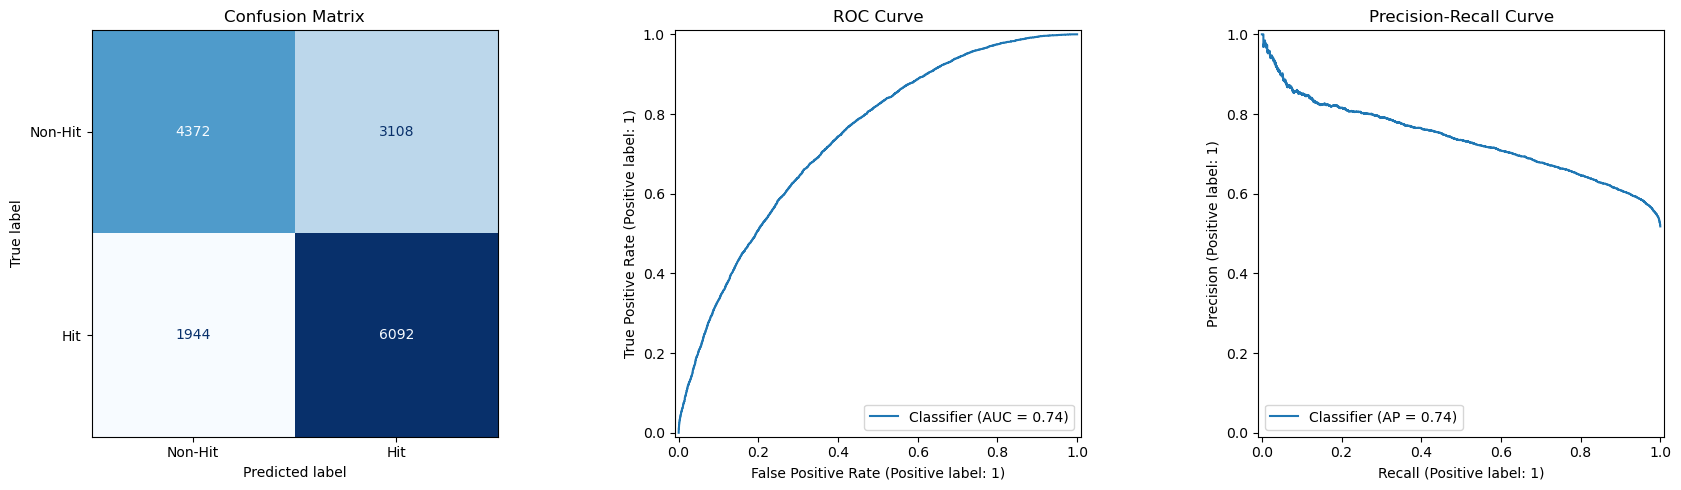

In [34]:
#Metrics
class_metrics(y_test, best_xgb_model, X_test)

## MLP classifier

In [44]:
#Define MLP classifier with 3 dense layers
mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=5e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=42
    )

In [45]:
history_mlp = mlp.fit(X_train_scaled,y_train)

Accuracy : 0.669
Precision: 0.6651
Recall   : 0.727
F1-score : 0.6946
ROC AUC  : 0.7305

Classification report:

              precision    recall  f1-score   support

     Non-Hit       0.67      0.61      0.64      7480
         Hit       0.67      0.73      0.69      8036

    accuracy                           0.67     15516
   macro avg       0.67      0.67      0.67     15516
weighted avg       0.67      0.67      0.67     15516


Metrics plots:



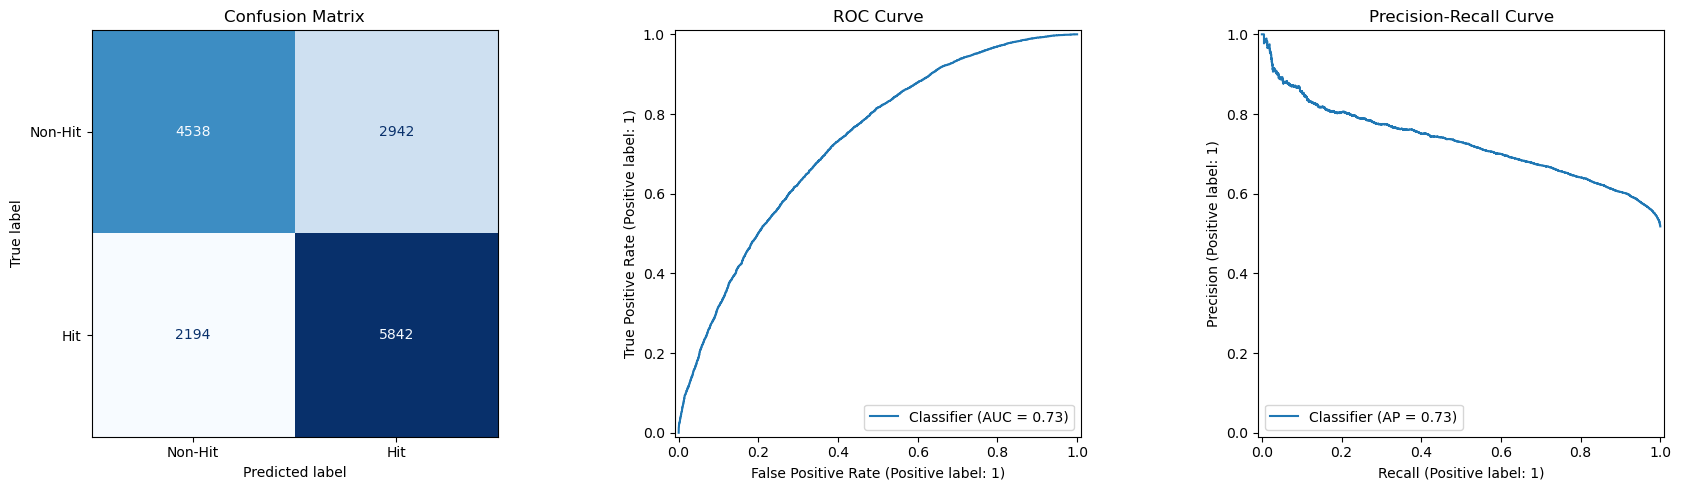

In [46]:
class_metrics(y_test, mlp, X_test_scaled)

## ResNet

Code: https://www.geeksforgeeks.org/deep-learning/residual-networks-resnet-deep-learning/

In [47]:
#Define the residual block
def residual_block(x, units, dropout_rate=0.3):
    shortcut = x
    
    x = layers.Dense(units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    
    x = layers.Dense(units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units)(shortcut)
        
    x = layers.Add()([x, shortcut])
    return x

In [48]:
inputs = layers.Input(shape=(n_cols,))
x = layers.BatchNormalization()(inputs)
x = residual_block(x, 128)
x = residual_block(x, 64)
x = residual_block(x, 32)
outputs = layers.Dense(1, activation='sigmoid')(x)

E0000 00:00:1779230865.705310     222 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [51]:
resnet = models.Model(inputs=inputs, outputs=outputs)

resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy', 
        tf.keras.metrics.AUC(name='auc') 
    ]
)

In [52]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_resnet = resnet.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_scaled, y_test),
    callbacks=[callback]
)

Epoch 1/100
970/970 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5882 - auc: 0.6160 - loss: 0.7107 - val_accuracy: 0.6384 - val_auc: 0.6872 - val_loss: 0.6374
Epoch 2/100
970/970 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6191 - auc: 0.6631 - loss: 0.6529 - val_accuracy: 0.6411 - val_auc: 0.6916 - val_loss: 0.6338
Epoch 3/100
970/970 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6288 - auc: 0.6760 - loss: 0.6445 - val_accuracy: 0.6426 - val_auc: 0.6956 - val_loss: 0.6329
Epoch 4/100
970/970 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6337 - auc: 0.6838 - loss: 0.6389 - val_accuracy: 0.6472 - val_auc: 0.7006 - val_loss: 0.6269
Epoch 5/100
970/970 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6391 - auc: 0.6892 - loss: 0.6358 - val_accuracy: 0.6496 - val_auc: 0.7056 - val_loss: 0.6245
Epoch 6/100
970/970 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6420 - auc: 0.6948 - loss: 0.6313 - val_accuracy: 0.6548 - val_auc: 0.7128 - val_loss: 0.6179
Epoch 7/100
970/970 ━━━━━━━━━━━━━

In [55]:
#Here there is not predict_proba
y_prob_res = resnet.predict(X_test_scaled).flatten()
y_pred_res = (y_prob_res > 0.5).astype(int) #Get the label

485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step


Accuracy : 0.6691
Precision: 0.659
Recall   : 0.7485
F1-score : 0.7009
ROC AUC  : 0.7349

Classification report:

              precision    recall  f1-score   support

           0     0.6836    0.5838    0.6298      7480
           1     0.6590    0.7485    0.7009      8036

    accuracy                         0.6691     15516
   macro avg     0.6713    0.6662    0.6653     15516
weighted avg     0.6709    0.6691    0.6666     15516


Metrics plots:



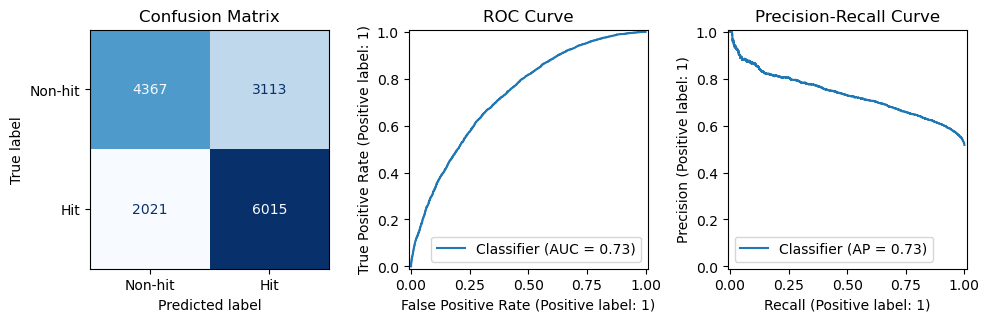

In [56]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_res), 4))
print("Precision:", round(precision_score(y_test, y_pred_res), 4))
print("Recall   :", round(recall_score(y_test, y_pred_res), 4))
print("F1-score :", round(f1_score(y_test, y_pred_res), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_res), 4))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_res, digits=4))

print("\nMetrics plots:\n")
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_res,
    display_labels=["Non-hit", "Hit"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob_res, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob_res, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

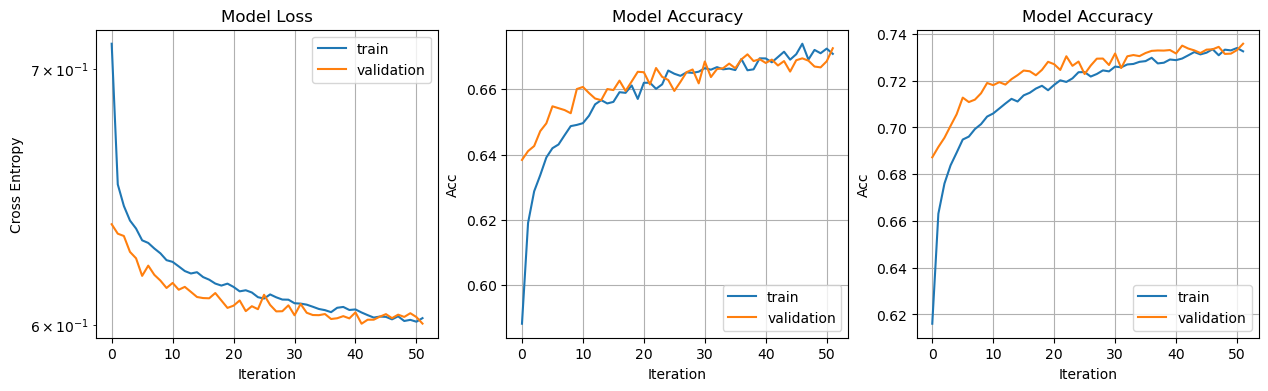

In [58]:
#PLot the training performance
plt.figure(figsize = (15,4))
plt.subplot(131)
plt.plot(history_resnet.history['loss'],label="train")
plt.plot(history_resnet.history['val_loss'],label="validation")
plt.title('Model Loss')
plt.yscale('log')
plt.ylabel('Cross Entropy')
plt.xlabel('Iteration')
plt.grid()
plt.legend()
#print("history",history_resnet.history)
plt.subplot(132)
plt.plot(history_resnet.history['accuracy'],label="train")
plt.plot(history_resnet.history['val_accuracy'],label="validation")
plt.title('Model Accuracy')
#plt.yscale('log')
plt.ylabel('Acc')
plt.xlabel('Iteration')
plt.grid()
plt.legend()
plt.subplot(133)
plt.plot(history_resnet.history['auc'],label="train")
plt.plot(history_resnet.history['val_auc'],label="validation")
plt.title('Model Accuracy')
#plt.yscale('log')
plt.ylabel('Acc')
plt.xlabel('Iteration')
plt.grid()
plt.legend()
plt.show()

## TabNet **GPU is needed here**

https://www.geeksforgeeks.org/machine-learning/tabnet/

In [22]:
tabnet = TabNetClassifier(
    n_d=32, n_a=32, 
    n_steps=5,
    gamma = 1.5,
    device_name='cuda',
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.0001),
mask_type='sparsemax'
)

/opt/conda/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [27]:
history_tabnet = tabnet.fit(
    X_train=X_train_scaled, y_train=y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy', 'logloss'],
    max_epochs=150, 
    patience=20,
    batch_size=256, 
    virtual_batch_size=128,
    num_workers=0 
)

epoch 0  | loss: 1.1495  | train_accuracy: 0.50722 | train_logloss: 0.91262 | valid_accuracy: 0.50174 | valid_logloss: 0.90807 |  0:00:10s
epoch 1  | loss: 0.96925 | train_accuracy: 0.51026 | train_logloss: 0.85202 | valid_accuracy: 0.50748 | valid_logloss: 0.85505 |  0:00:22s
epoch 2  | loss: 0.87259 | train_accuracy: 0.51747 | train_logloss: 0.79622 | valid_accuracy: 0.51708 | valid_logloss: 0.7934  |  0:00:33s
epoch 3  | loss: 0.8249  | train_accuracy: 0.53052 | train_logloss: 0.76434 | valid_accuracy: 0.52868 | valid_logloss: 0.75992 |  0:00:45s
epoch 4  | loss: 0.79931 | train_accuracy: 0.5412  | train_logloss: 0.7409  | valid_accuracy: 0.54099 | valid_logloss: 0.73563 |  0:00:56s
epoch 5  | loss: 0.77541 | train_accuracy: 0.549   | train_logloss: 0.72531 | valid_accuracy: 0.54963 | valid_logloss: 0.72714 |  0:01:08s
epoch 6  | loss: 0.76349 | train_accuracy: 0.55423 | train_logloss: 0.7198  | valid_accuracy: 0.55304 | valid_logloss: 0.71882 |  0:01:20s
epoch 7  | loss: 0.75085 | 

/opt/conda/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Accuracy : 0.6297
Precision: 0.6224
Recall   : 0.7246
F1-score : 0.6696
ROC AUC  : 0.6791

Classification report:

              precision    recall  f1-score   support

     Non-Hit       0.64      0.53      0.58      7480
         Hit       0.62      0.72      0.67      8036

    accuracy                           0.63     15516
   macro avg       0.63      0.63      0.62     15516
weighted avg       0.63      0.63      0.63     15516


Metrics plots:



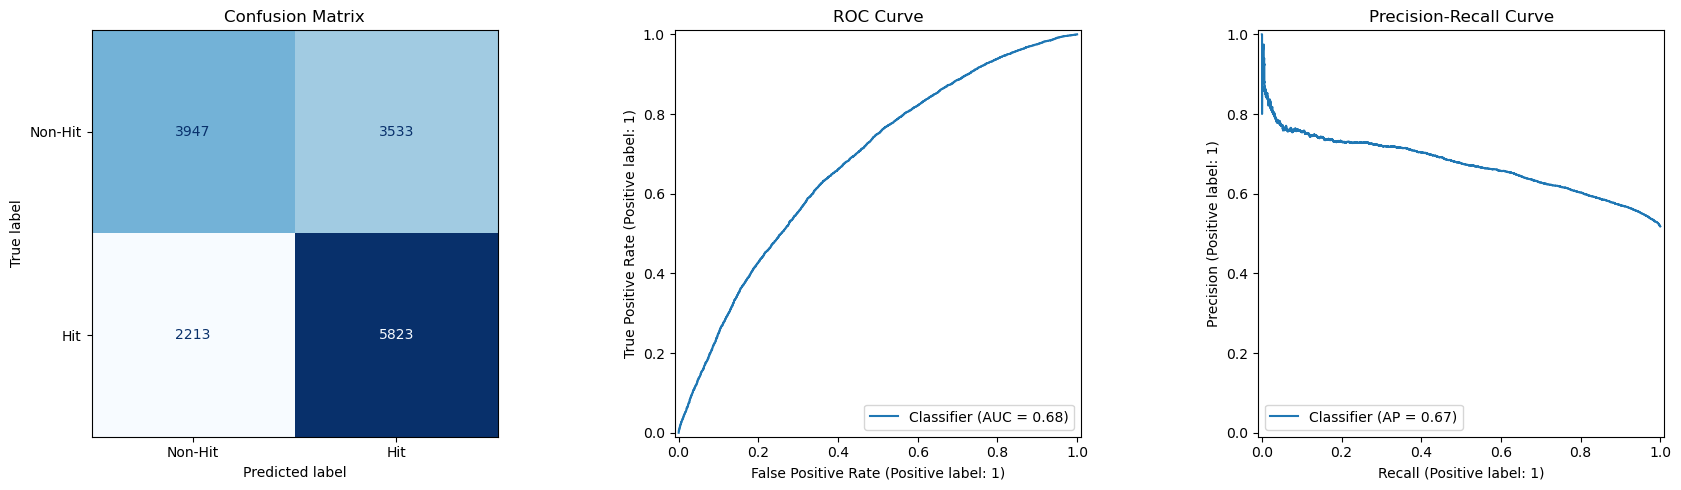

In [30]:
class_metrics(y_test, tabnet, X_test_scaled)

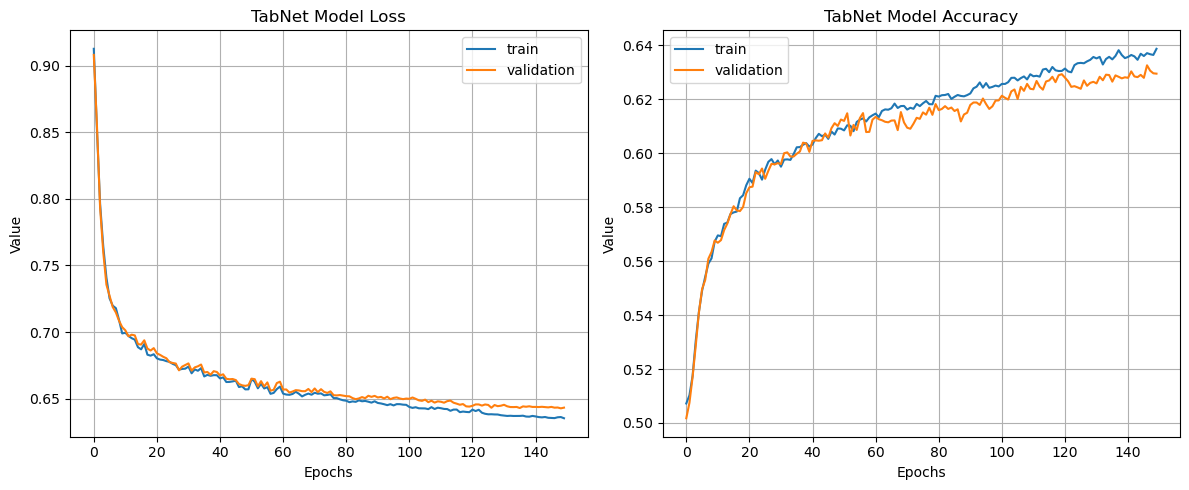

In [31]:
plt.figure(figsize = (12,5))
plt.subplot(121)
plt.plot(tabnet.history['train_logloss'], label="train")
plt.plot(tabnet.history['valid_logloss'], label="validation")
plt.title('TabNet Model Loss')
plt.ylabel('Value')
plt.xlabel('Epochs')
plt.grid(True)
plt.legend()
plt.subplot(122)
plt.plot(tabnet.history['train_accuracy'], label="train")
plt.plot(tabnet.history['valid_accuracy'], label="validation")
plt.title('TabNet Model Accuracy')
plt.ylabel('Value')
plt.xlabel('Epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Comparison between models

Define fucntion to get metrics, accuracy since it is balanced dataset, f1 for precision and recall, roc_auc for robustness

In [59]:
def evaluation(y_test, model, X_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = round(accuracy_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)
    roc = round(roc_auc_score(y_test, y_prob), 4)

    return accuracy, f1, roc

In [61]:
acc_res, f1_res, roc_res = round(accuracy_score(y_test, y_pred_res), 4), round(f1_score(y_test, y_pred_res), 4), round(roc_auc_score(y_test, y_prob_res), 4)

In [62]:
acc_lgr, f1_lgr, roc_lgr = evaluation(y_test, lgr, X_test_scaled)
acc_xgb, f1_xgb, roc_xgb = evaluation(y_test, best_xgb_model, X_test)
acc_mlp, f1_mlp, roc_mlp = evaluation(y_test, mlp, X_test_scaled)

In [38]:
#Just run when TabNet, its values will be stored in a vector to don't compile again
acc_tab, f1_tab, roc_tab = evaluation(y_test, tabnet, X_test_scaled)
acc_tab, f1_tab, roc_tab

(0.6297, 0.6696, np.float64(0.6791))

In [63]:
acc_tab, f1_tab, roc_tab = (0.6297, 0.6696, np.float64(0.6791))

In [64]:
comp = {'Model': ['Baseline (Logistic)', 'XGBoost', 'MLP classifier', 'Resnet', 'TabNet'], 
        'Accuracy': [acc_lgr, acc_xgb, acc_mlp, acc_res, acc_tab],
        'F1-Score': [f1_lgr, f1_xgb, f1_mlp, f1_res, f1_tab],
        'ROC_AUC': [roc_lgr, roc_xgb, roc_mlp, roc_res, roc_tab]
       }

In [65]:
df_comp = pd.DataFrame(data=comp)
df_comp.sort_values('Accuracy', ascending = False)

,Model,Accuracy,F1-Score,ROC_AUC
1,XGBoost,0.6744,0.7069,0.7394
3,Resnet,0.6691,0.7009,0.7349
2,MLP classifier,0.6690,0.6946,0.7305
4,TabNet,0.6297,0.6696,0.6791
0,Baseline (Logistic),0.5925,0.6313,0.6344
